# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 5     |  |
| :-------------|:-------------|
|Farzat Darboli|6535925|
| Shahraan Rahimbaksh| 6500803 |
| Ocean Hamerlinck | 6583202 |

| Planning Groep: 5     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12:30 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 15:30 |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](Schetsen.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR| Alarm bij binnenkomst deur | Sensor moet stijging van 10 lux naar 1000 lux kunnen detecteren binnen 0,5 seconden met onzekerheid van 10 % lux|
|| |  |
|| | Criteria omschrijving |
|Thermistor|stanley cup, die de temperatuur van binnen in de cup kan meten|  temperatuur moet buitenkant van de stanley cup tussen 21 en 100 graden celcius zijn en met een onzekerheid van max 5 Celsius |
||  | | 
||  | Criteria omschrijving |
|Force sensor | seintje geven als bakje met kopjes van koffiemachine leeg is |  Sensor moet een verschil tussen 1 plastic kopje (ongeveer 0,12 Newton) en geen kopje kunnen detecteren met een maximale onzekerheid van 0.01 Newton  |
| |  omschrijving |  |
| |  omschrijving | Criteria omschrijving |

Groep 5 heeft gekozen voor sensor Thermistor sensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Op de foto is de schets van onze elektrisch circuit te zien die wij gebruiken voor de meetopstelling. Daarnaast is de schets van de meetopstelling zelf waarbij de sensor boven het water laten hangen en verschillende temperaturen gaan meten.
 ![Alt](Meetopstelling.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? Temperatuur
2. Over welk bereik ga je deze variabelen veranderen? Temperatuur van kamer temp. (21 Graden Celsius) tot het kookpunt van water (100 Graden Celsius)
3. Wat ga je allemaal meten? Ruwe ADC waardes van Arduino en de temperatuur in graden celsius
4. Hoeveel metingen ga je doen? de metingen gaan in stappen van 10 graden celcius. Wij doen 3 metingen per datapunt
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
ja


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Op de foto is de echte meetopstelling te zien met sensor hangend boven het kopje.
 ![Alt](Meetopstelling2.jpeg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [8]:
#Data
#libs
import numpy as np
import matplotlib.pyplot as mpl
from scipy.optimize import curve_fit
"""
----OUD---

m_temps = np.array([75,65,55,45,
                    70,60,50.6,40.5,35,
                    68.2,63.3,58.2,53.2,48.2])

m_volts = np.array([746,622,548,570,
                    702,604,565,495,487,
                    600,553,550,548,532])

m_temps = np.array([55.6,50.5,45.5,40.6,35.6])

m_volts = np.array([821,782,750,727,703])"""

m_temps = np.array([68,63,58,53,48,43,38,33])

m_bits = np.array([846,820,773,715,630,603,570,500])

temps,bits = zip(*sorted(zip(m_temps,m_bits)))
temps,bits = np.array(temps),np.array(bits)

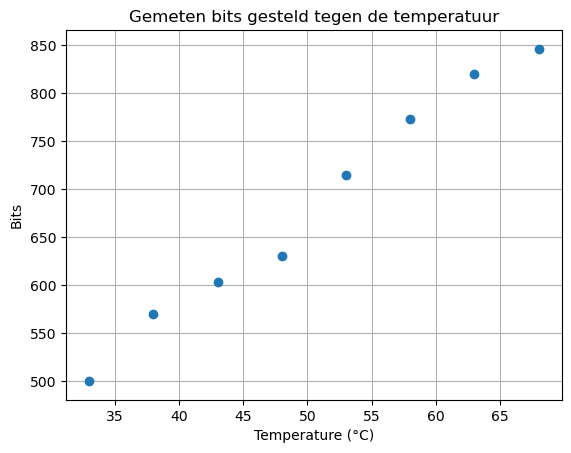

quadratic: 36.832143134132025*x^(0.7454920719431114)


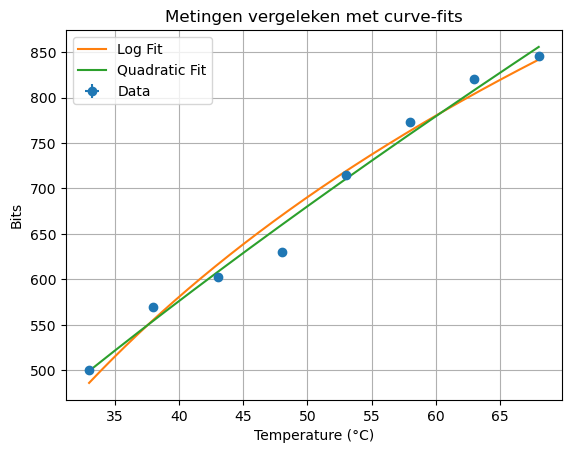

In [9]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.

u_temps = 0.05
u_bits = 2 #bits, dit is een afleesfout 

mpl.errorbar(temps,bits,u_bits,u_temps,"o")
mpl.xlabel("Temperature (°C)")
mpl.ylabel("Bits")
mpl.title("Gemeten bits gesteld tegen de temperatuur")
mpl.grid()
mpl.show()

#Curve-fit
def log(x,a,b): return a*np.log(x)+b
def quad(x,a,b): return a*x**b

poptlog,pcovlog = curve_fit(log,temps,bits)
poptquad,pcovquad = curve_fit(quad,temps,bits)


mpl.errorbar(temps,bits,u_bits,u_temps,'o',label = "Data")

tempsHD = np.linspace(temps.min(),temps.max(),1000)
diff_log = np.abs(log(temps,*poptlog)-bits)
diff_quad = np.abs(quad(temps,*poptquad)-bits)
print({False: f"quadratic: {poptquad[0]}*x^({poptquad[1]})",True: f"log: {poptlog[0]}*ln(x) + {poptlog[1]}"}[diff_log.mean()<diff_quad.mean()])

mpl.plot(tempsHD,log(tempsHD,*poptlog),label = "Log Fit")
mpl.plot(tempsHD,quad(tempsHD,*poptquad),label = "Quadratic Fit")

mpl.xlabel("Temperature (°C)")
mpl.ylabel("Bits")
mpl.title("Metingen vergeleken met curve-fits")
mpl.grid()
mpl.legend()
mpl.show()



## *Opdracht 7*: Iteratie nodig?

In het begin hebben we verkeerde waardes afgelezen, doordat de sensor niet goed werkte. Hierdoor hebben we veel tijd verloren. Daarom hebben we nu de sensor in het water gezet, dus niet aan de buitenkant. Het aantal stappen die wij genomen worden moesten wij van 10 naar 5 veranderen vanwege tijd. Het bereik hebben we ook aangepast van 35 naar 70, ook vanwege tijd.

Ofwel de criteria is nu:de temperatuur in de cup tussen 35 graden is en 70 graden met een onzekerheid van 5 graden celcius.

## *Opdracht 8*: Conclusie, leerdoel

De grafiek is lineair. Dit hadden we ook verwacht, omdat de temperatuur daalt en daarbij ook de spanning. 

Onze onzekerheid in de grafiek is voor de temperatuur 0.05 graden celsius en voor de spanning 0.5 volt. Dit is zo klein en kan je dus niet zien op de grafiek. 

De sensor is te onbetrouwbaar om te kunnen gebruiken omdat bij elke set metingen hij compleet andere waardes aangaf.

De punten die gemeten worden zijn niet betrouwbaar genoeg om de sensor te gebruiken voor de toepassing volgens onze nieuwe criteria.




## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Op de foto is de schets van onze elektrisch circuit te zien die wij gebruiken voor de meetopstelling. Daarnaast is de schets van de meetopstelling zelf waarbij de sensor boven het water laten hangen en verschillende temperaturen gaan meten.
 ![Alt](Meetopstelling.jpeg "schets student")

 ## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Op de foto is de echte meetopstelling te zien met sensor hangend boven het kopje.
 ![Alt](Meetopstelling2.jpeg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR| Alarm bij binnenkomst deur | Sensor moet stijging van 10 lux naar 1000 lux kunnen detecteren binnen 0,5 seconden met onzekerheid van 10 % lux|
|| |  |
|| | Criteria omschrijving |
|Thermistor|stanley cup, die de temperatuur van binnen in de cup kan meten|  temperatuur moet buitenkant van de stanley cup tussen 21 en 100 graden celcius zijn en met een onzekerheid van max 5 Celsius |
||  | | 
||  | Criteria omschrijving |
|Force sensor | seintje geven als bakje met kopjes van koffiemachine leeg is |  Sensor moet een verschil tussen 1 plastic kopje (ongeveer 0,12 Newton) en geen kopje kunnen detecteren met een maximale onzekerheid van 0.01 Newton  |
| |  omschrijving |  |
| |  omschrijving | Criteria omschrijving |

Groep 5 heeft gekozen voor sensor Thermistor sensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

 ## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Op de foto is de echte meetopstelling te zien met sensor hangend boven het kopje.
 ![Alt](Meetopstelling2.jpeg "meetopstelling student")

quadratic: 36.832143134132025*x^(0.7454920719431114)


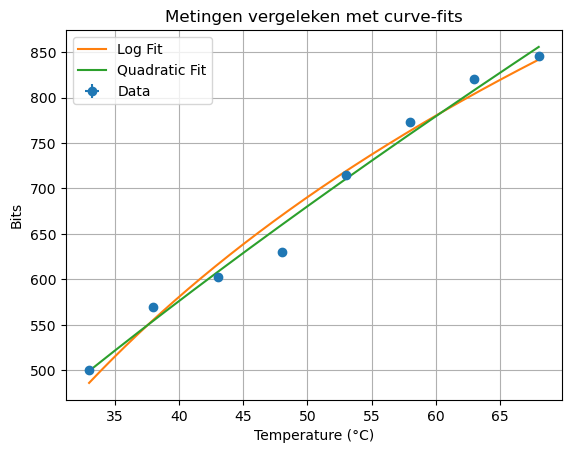

In [10]:
#Curve-fit
def log(x,a,b): return a*np.log(x)+b
def quad(x,a,b): return a*x**b

poptlog,pcovlog = curve_fit(log,temps,bits)
poptquad,pcovquad = curve_fit(quad,temps,bits)


mpl.errorbar(temps,bits,u_bits,u_temps,'o',label = "Data")

tempsHD = np.linspace(temps.min(),temps.max(),1000)
diff_log = np.abs(log(temps,*poptlog)-bits)
diff_quad = np.abs(quad(temps,*poptquad)-bits)
print({False: f"quadratic: {poptquad[0]}*x^({poptquad[1]})",True: f"log: {poptlog[0]}*ln(x) + {poptlog[1]}"}[diff_log.mean()<diff_quad.mean()])

mpl.plot(tempsHD,log(tempsHD,*poptlog),label = "Log Fit")
mpl.plot(tempsHD,quad(tempsHD,*poptquad),label = "Quadratic Fit")

mpl.xlabel("Temperature (°C)")
mpl.ylabel("Bits")
mpl.title("Metingen vergeleken met curve-fits")
mpl.grid()
mpl.legend()
mpl.show()


## *Opdracht 8*: Conclusie, leerdoel

De grafiek is lineair. Dit hadden we ook verwacht, omdat de temperatuur daalt en daarbij ook de spanning. 

Onze onzekerheid in de grafiek is voor de temperatuur 0.05 graden celsius en voor de spanning 0.5 volt. Dit is zo klein en kan je dus niet zien op de grafiek. 

De sensor is te onbetrouwbaar om te kunnen gebruiken omdat bij elke set metingen hij compleet andere waardes aangaf.

De punten die gemeten worden zijn niet betrouwbaar genoeg om de sensor te gebruiken voor de toepassing volgens onze nieuwe criteria.